# 01 · Análisis exploratorio

Clasificación de género musical a partir de letras de canciones. Corpus: "5 Million Song Lyrics" (Kaggle, versión 3), compuesto por letras publicadas en Genius.

El análisis se organiza en dos niveles. El primero describe el corpus completo (5,9 millones de canciones) a partir de `metadatos.parquet`, que contiene una fila por canción con atributos derivados de la letra, pero no la letra misma. El segundo describe la muestra de trabajo, de 10.000 canciones por género, a partir de `candidatas.parquet` y `muestra.parquet`.

Estos archivos se generan con `python -m src.muestra`, que recorre dos veces el archivo comprimido y aplica la detección de idioma (alrededor de 25 minutos en total). El notebook solo los lee. Las figuras se guardan en `reports/figures` y las tablas en `reports/tablas`. La celda siguiente define las rutas, el estilo de las figuras y dos funciones auxiliares.

In [1]:
import re
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from src.datos import GENEROS, SEMILLA, limpiar_letra
from src.muestra import BLOQUE_IMPORTADO, MIN_PALABRAS, preparar_muestra

PROC = RAIZ / "data" / "processed"
FIG = RAIZ / "reports" / "figures"
TAB = RAIZ / "reports" / "tablas"
TAB.mkdir(parents=True, exist_ok=True)
for archivo in ["metadatos.parquet", "candidatas.parquet", "muestra.parquet", "marcadores.parquet"]:
    assert (PROC / archivo).exists(), f"Falta {archivo}; se genera con `python -m src.muestra` desde la raíz del repositorio"

pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:,.1f}".format)

# Color fijo por género en todas las figuras (paleta categórica apta para daltonismo).
NOMBRE = {"pop": "Pop", "rap": "Rap", "rock": "Rock", "rb": "R&B", "country": "Country"}
COLOR = {"pop": "#2a78d6", "rap": "#eb6834", "rock": "#1baf7a", "rb": "#eda100", "country": "#e87ba4"}
TINTA, TINTA_2, GRILLA = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 9, "axes.titlesize": 9.5, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.edgecolor": TINTA_2, "axes.labelcolor": TINTA_2, "xtick.color": TINTA_2,
    "ytick.color": TINTA_2, "text.color": TINTA, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRILLA, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False, "font.family": "Arial",
})


def guardar(fig, nombre):
    fig.savefig(FIG / f"{nombre}.png", bbox_inches="tight", facecolor="white")


def por_genero(serie_o_df):
    """Reordena el índice según GENEROS (pop, rap, rock, rb, country)."""
    return serie_o_df.reindex(GENEROS)

## 1. Corpus completo

### 1.1 Distribución de géneros

Cantidad de canciones por etiqueta (`tag`) en el corpus completo.

In [2]:
meta = pd.read_parquet(PROC / "metadatos.parquet")
conteo = meta["tag"].value_counts()
print(f"{len(meta):,} canciones, {meta['artist'].nunique():,} artistas")
pd.DataFrame({"canciones": conteo, "% del total": conteo / len(meta) * 100})

5,913,411 canciones, 698,390 artistas


,canciones,% del total
tag,,
pop,2519256,42.6
rap,1962010,33.2
rock,892220,15.1
rb,225342,3.8
misc,208714,3.5
country,105869,1.8


La categoría `misc` no corresponde a un género musical. Para caracterizar su contenido se listan los veinte valores más frecuentes de `artist` dentro de ella.

In [3]:
misc = meta.loc[meta["tag"] == "misc", "artist"].value_counts()
print(f"misc: {misc.sum():,} textos de {len(misc):,} 'artistas'; los 20 más frecuentes suman el "
      f"{misc.head(20).sum() / misc.sum():.1%}")
(misc.head(20) / misc.sum() * 100).rename("% de misc").to_frame()

misc: 208,714 textos de 51,860 'artistas'; los 20 más frecuentes suman el 8.2%


,% de misc
artist,
Emily Dickinson,0.8
Abraham Lincoln,0.7
William Shakespeare,0.6
Holy Bible (KJV),0.6
La Bible de Jrusalem,0.6
Charles Dickens,0.5
(Leo Tolstoy),0.5
Thomas Hardy,0.5
Gajanan Mishra,0.4


Entre los autores más frecuentes figuran escritores (Emily Dickinson, Shakespeare, Dickens, Tolstói, Whitman), discursos (Abraham Lincoln) y textos religiosos (Biblia King James, Biblia de Jerusalén), además de cuentas de plataformas (Spotify, Genius) y listados deportivos ("Home Runs of the Day"). Otros dos indicadores apuntan en la misma dirección: el 12% de los textos de `misc` supera los 10.000 caracteres, frente a valores de entre 0,01% y 0,14% en los géneros musicales (sección 1.3), y el 80% de los registros con año anterior a 1900 pertenece a esta categoría (sección 1.4).

Estos veinte autores reúnen solo el 8,2% de los textos de la categoría; el resto se distribuye entre más de 51.000 valores de `artist`. La caracterización es, por lo tanto, parcial, y estimar la proporción de textos no musicales requeriría anotar manualmente una muestra aleatoria. La categoría se excluye del análisis por no constituir un género musical.

### 1.2 Orden del archivo y bloque de importación

El CSV está ordenado por el identificador de Genius, que crece con la fecha de alta de cada canción en el sitio. La celda siguiente divide el archivo en veinte tramos de igual tamaño y calcula, para cada uno, el rango de identificadores, el año mediano, la proporción de letras con encabezados de sección y la distribución de géneros. La figura posterior muestra la proporción de pop y de rap en una ventana móvil de 20.000 canciones.

In [4]:
meta["tramo"] = pd.cut(meta["fila"], np.linspace(0, len(meta), 21), labels=False, include_lowest=True)
tramos = meta.groupby("tramo").agg(
    id_desde=("id", "min"), id_hasta=("id", "max"), año_mediano=("year", "median"),
    con_encabezados=("n_encabezados", lambda s: (s > 0).mean() * 100),
)
tramos = tramos.join(pd.crosstab(meta["tramo"], meta["tag"], normalize="index")[GENEROS + ["misc"]] * 100)
tramos

,id_desde,id_hasta,año_mediano,con_encabezados,pop,rap,rock,rb,country,misc
tramo,,,,,,,,,,
0,1,422033,"2,012.0",63.3,2.8,59.6,13.4,1.2,1.9,21.1
1,402290,883657,"2,011.0",43.6,40.7,27.3,16.2,2.5,3.5,9.8
2,881881,1216527,"2,004.0",14.0,85.7,0.8,10.7,1.0,1.6,0.2
3,1189689,1513596,"2,004.0",13.9,86.0,0.7,10.6,1.0,1.6,0.1
4,1498962,1822362,"2,005.0",15.5,84.6,2.1,10.3,1.1,1.7,0.4
5,1821153,2378719,"2,015.0",34.5,77.4,10.3,7.8,1.5,1.0,1.9
6,2312560,3012194,"2,016.0",68.5,16.7,50.9,17.6,5.0,1.5,8.3
7,3010282,3391157,"2,017.0",62.3,23.2,43.2,19.1,5.1,1.3,8.2
8,3369074,3792546,"2,017.0",60.3,30.5,38.6,21.8,4.4,2.7,1.8


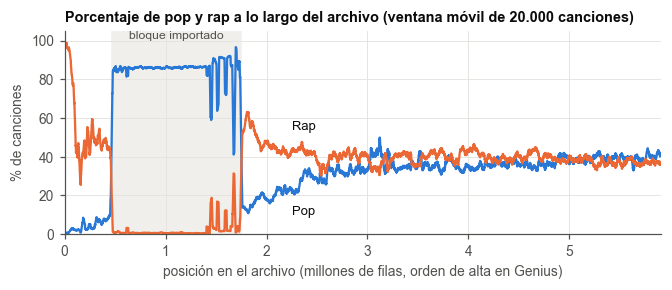

In [5]:
porc_pop = meta["tag"].eq("pop").rolling(20_000, center=True).mean() * 100
porc_rap = meta["tag"].eq("rap").rolling(20_000, center=True).mean() * 100
fig, ax = plt.subplots(figsize=(7, 2.4))
x = meta["fila"] / 1e6
ax.axvspan(BLOQUE_IMPORTADO[0] / 1e6, BLOQUE_IMPORTADO[1] / 1e6, color="#f0efec", zorder=0)
ax.plot(x[::500], porc_pop[::500], color=COLOR["pop"], lw=1.5)
ax.plot(x[::500], porc_rap[::500], color=COLOR["rap"], lw=1.5)
ax.text(2.25, 54, "Rap", color=TINTA, fontsize=8.5)
ax.text(2.25, 10, "Pop", color=TINTA, fontsize=8.5)
ax.text(np.mean(BLOQUE_IMPORTADO) / 1e6, 101, "bloque importado", ha="center", color=TINTA_2, fontsize=8)
ax.set(xlabel="posición en el archivo (millones de filas, orden de alta en Genius)", ylabel="% de canciones",
       ylim=(0, 105), xlim=(0, len(meta) / 1e6))
ax.set_title("Porcentaje de pop y rap a lo largo del archivo (ventana móvil de 20.000 canciones)")
guardar(fig, "orden_archivo_bloque_importado")

Los primeros tramos están dominados por el rap, lo que es consistente con el origen del sitio como *Rap Genius*. Entre las filas 470.000 y 1.745.000 aparece un tramo en el que el pop supera el 80% de las canciones. Sus límites, definidos en `BLOQUE_IMPORTADO` (`src/muestra.py`), corresponden a los puntos en que la ventana móvil de pop cruza el 70%. El tramo contiene alrededor de 1,27 millones de canciones con un perfil distinto al del resto del archivo: año mediano más antiguo, muy pocos encabezados de sección y artistas de catálogo de géneros diversos.

Para evaluar si en ese tramo la etiqueta pop describe un género o funciona como valor por defecto, la primera celda compara las etiquetas de un mismo artista dentro y fuera del bloque. La segunda calcula, por género, la proporción de canciones que provienen del bloque y la presencia de encabezados dentro y fuera de él.

In [6]:
meta["en_bloque"] = meta["fila"].between(*BLOQUE_IMPORTADO)
artistas = ["Status Quo", "Van Morrison", "B.B. King", "Muddy Waters", "Johnny Cash", "Dolly Parton",
            "Los Tigres Del Norte", "Metallica"]
ej = meta[meta["artist"].isin(artistas)]
tabla_ej = (ej.groupby(["artist", "en_bloque"])["tag"].value_counts().unstack(fill_value=0)
            [["pop", "rock", "country", "rb"]].unstack("en_bloque", fill_value=0))
tabla_ej.columns = [f"{t} ({'dentro' if b else 'fuera'})" for t, b in tabla_ej.columns]
tabla_ej[[c for c in tabla_ej.columns if "fuera" in c] + [c for c in tabla_ej.columns if "dentro" in c]].loc[artistas]

,pop (fuera),rock (fuera),country (fuera),rb (fuera),pop (dentro),rock (dentro),country (dentro),rb (dentro)
artist,,,,,,,,
Status Quo,20,14,0,0,437,9,0,0
Van Morrison,46,176,1,1,529,40,0,2
B.B. King,10,4,0,5,464,4,0,88
Muddy Waters,4,65,2,53,81,2,0,10
Johnny Cash,1,5,824,0,145,16,54,0
Dolly Parton,23,1,588,0,69,0,18,0
Los Tigres Del Norte,1,2,45,0,480,0,0,0
Metallica,0,353,0,0,8,40,0,0


In [7]:
resumen = pd.DataFrame({
    "% del género en el bloque": meta.groupby("tag")["en_bloque"].mean() * 100,
    "% con encabezados (fuera)": meta[~meta["en_bloque"]].groupby("tag")["n_encabezados"].apply(lambda s: (s > 0).mean() * 100),
    "% con encabezados (dentro)": meta[meta["en_bloque"]].groupby("tag")["n_encabezados"].apply(lambda s: (s > 0).mean() * 100),
})
por_genero(resumen)

,% del género en el bloque,% con encabezados (fuera),% con encabezados (dentro)
tag,,,
pop,43.0,65.0,13.6
rap,1.5,73.6,74.5
rock,13.9,48.8,36.3
rb,6.3,66.5,69.0
country,18.3,58.6,30.7


En el bloque, artistas de rock, blues, country y música norteña figuran mayoritariamente como pop (Status Quo, por ejemplo, tiene 437 canciones etiquetadas como pop dentro del bloque y 14 como rock fuera de él). El bloque aporta el 43% de todo el pop del corpus, por lo que se excluye de la muestra.

### 1.3 Textos que no son letras

Durante la lectura del archivo se calcula un hash de 64 bits de cada letra en minúsculas (`_hash_letra` en `src/muestra.py`). Un texto repetido cientos de veces entre artistas distintos no puede ser una letra: corresponde a los marcadores que el sitio muestra cuando la letra no está disponible. La primera celda lista los textos más repetidos y la segunda cuantifica, por género, la proporción de canciones afectadas y la distribución de longitudes.

In [8]:
repetida = meta["hash_letra"].duplicated(keep=False)
print(f"canciones cuyo texto aparece más de una vez: {repetida.mean():.1%} ({repetida.sum():,})")
marcadores = pd.read_parquet(PROC / "marcadores.parquet")
marcadores.assign(texto=marcadores["lyrics"].fillna("<vacío>").str.slice(0, 70).map(repr))[["veces", "texto"]].head(20)

canciones cuyo texto aparece más de una vez: 14.0% (826,223)


,veces,texto
0,625720,'[Instrumental]'
1,4116,'.'
2,3561,'[?]'
3,2464,'<vacío>'
4,1702,'...'
5,1414,'The lyrics for this song have yet to be transcribed'
6,1379,'This music does not contain words'
7,1342,'[Strumentale]'
8,1286,'-'
9,1227,'[Instrumental track]'


In [9]:
instrumental = meta["hash_letra"] == meta["hash_letra"].value_counts().index[0]
largo = pd.DataFrame({
    "% '[Instrumental]'": meta.assign(i=instrumental).groupby("tag")["i"].mean() * 100,
    "% texto repetido": meta.assign(r=repetida).groupby("tag")["r"].mean() * 100,
    "% < 100 caracteres": meta.groupby("tag")["n_chars"].apply(lambda s: (s < 100).mean() * 100),
    "% > 10.000 caracteres": meta.groupby("tag")["n_chars"].apply(lambda s: (s > 10_000).mean() * 100),
    "caracteres (mediana)": meta.groupby("tag")["n_chars"].median(),
})
largo.reindex(GENEROS + ["misc"])

,% '[Instrumental]',% texto repetido,% < 100 caracteres,% > 10.000 caracteres,caracteres (mediana)
tag,,,,,
pop,13.3,17.7,15.1,0.0,904.0
rap,8.5,10.9,12.0,0.1,"1,872.0"
rock,9.3,11.6,11.0,0.0,871.0
rb,10.3,12.3,12.7,0.0,"1,280.0"
country,4.1,6.4,5.2,0.0,"1,031.0"
misc,6.7,13.5,12.7,12.1,"1,049.0"


### 1.4 Año de publicación

Se cuentan los valores de `year` fuera del rango plausible y se calculan cuantiles por género sobre los valores comprendidos entre 1900 y 2022.

In [10]:
año = meta["year"]
print(f"year < 1900: {(año < 1900).sum():,} (year == 1: {(año == 1).sum():,})   year > 2022: {(año > 2022).sum():,}")
print("en misc:", f"{meta.loc[año < 1900, 'tag'].eq('misc').mean():.0%} de los year < 1900")
validos = meta[meta["tag"].isin(GENEROS) & año.between(1900, 2022)]
cuantiles = validos.groupby("tag")["year"].quantile([.1, .25, .5, .75, .9]).unstack()
por_genero(cuantiles.astype(int))

year < 1900: 20,880 (year == 1: 1,864)   year > 2022: 988
en misc: 80% de los year < 1900


,0.1,0.2,0.5,0.8,0.9
tag,,,,,
pop,1992,2005,2015,2019,2021
rap,2011,2015,2018,2020,2021
rock,1993,2007,2015,2019,2021
rb,1991,2015,2018,2020,2021
country,1970,1994,2013,2019,2021


Los años anteriores a 1900 corresponden mayoritariamente a `misc`, donde reflejan fechas de obras literarias o religiosas. Los valores posteriores a 2022 (2023, 2024, 2057, 2100) superan la fecha de recolección del corpus y se interpretan como errores de carga; en la muestra se tratan como faltantes. La distribución temporal difiere entre géneros: la mediana del rap es 2018 y su primer cuartil, 2015, mientras que el 10% del country es anterior a 1970. En consecuencia, `year` es un confusor potencial de la relación entre letra y género.

### 1.5 Artistas

Se calcula la cantidad de canciones por artista, la proporción de artistas con canciones en más de un género y la concentración de cada género en sus artistas más prolíficos.

In [11]:
por_artista = meta[meta["tag"].isin(GENEROS)].groupby("artist").agg(n=("tag", "size"), n_tags=("tag", "nunique"))
mayoritario = (meta[meta["tag"].isin(GENEROS)].groupby(["artist", "tag"]).size()
               .groupby("artist").max())
print(f"artistas: {len(por_artista):,}   canciones por artista: mediana {por_artista['n'].median():.0f}, "
      f"p99 {por_artista['n'].quantile(.99):.0f}, máx {por_artista['n'].max():,}")
print(f"artistas con canciones en más de un género: {(por_artista['n_tags'] > 1).mean():.1%}, "
      f"que suman el {por_artista.loc[por_artista['n_tags'] > 1, 'n'].sum() / por_artista['n'].sum():.1%} de las canciones")
print(f"canciones en el género mayoritario de su artista: {mayoritario.sum() / por_artista['n'].sum():.1%}")
top1 = {}
for g in GENEROS:
    n = meta.loc[meta["tag"] == g, "artist"].value_counts()
    top1[g] = n.head(max(1, len(n) // 100)).sum() / n.sum() * 100
pd.DataFrame({"artistas": meta[meta["tag"].isin(GENEROS)].groupby("tag")["artist"].nunique(),
              "% canciones del 1% de artistas más prolíficos": pd.Series(top1)}).pipe(por_genero)

artistas: 669,368   canciones por artista: mediana 2, p99 107, máx 16,555


artistas con canciones en más de un género: 16.0%, que suman el 51.6% de las canciones
canciones en el género mayoritario de su artista: 89.7%


,artistas,% canciones del 1% de artistas más prolíficos
pop,294968,22.3
rap,340613,24.6
rock,94201,18.1
rb,57690,23.0
country,14398,28.1


La etiqueta se asigna a cada canción y no al artista: el 10,3% de las canciones no pertenece al género mayoritario de su artista. Aun así, el artista es un predictor fuerte del género, y en cada género el 1% de artistas más prolíficos reúne entre el 18% y el 28% de las canciones. Por ese motivo la partición entre entrenamiento y evaluación se agrupa por artista (secciones 7 y 8).

Entre los valores más frecuentes de `artist` aparecen además cuentas institucionales de Genius que publican traducciones y romanizaciones. La celda siguiente las identifica mediante la expresión regular `CUENTAS_GENIUS`.

In [12]:
from src.muestra import CUENTAS_GENIUS

cuentas = meta[meta["artist"].fillna("").str.match(CUENTAS_GENIUS)]
print(f"canciones de cuentas 'Genius ...': {len(cuentas):,} ({len(cuentas) / len(meta):.1%}) en {cuentas['artist'].nunique()} cuentas")
(cuentas.groupby("artist")["tag"].value_counts().unstack(fill_value=0)[GENEROS]
 .assign(total=lambda d: d.sum(axis=1)).sort_values("total", ascending=False).head(8))

canciones de cuentas 'Genius ...': 74,350 (1.3%) en 151 cuentas


tag,pop,rap,rock,rb,country,total
artist,,,,,,
Genius Romanizations,13240,1210,1311,772,22,16555
Genius English Translations,8892,3900,1101,596,39,14528
Genius Brasil Tradues,3933,2487,1655,618,92,8785
Genius Traducciones al Espaol,3944,2064,767,458,95,7328
Genius Traductions Franaises,2216,1710,355,375,79,4735
Genius Trke eviri,1687,1691,333,315,63,4089
Genius Russian Translations ( ),850,1912,204,139,14,3119
Genius Deutsche bersetzungen,1068,508,137,75,6,1794


La cuenta "Genius English Translations", por ejemplo, publica traducciones al inglés de canciones escritas originalmente en otros idiomas. Estos textos superarían el filtro de idioma sin ser letras originales en inglés y, además, agrupan bajo un único valor de `artist` canciones de cientos de artistas distintos, lo que invalida la partición por artista. Por ambas razones se excluyen todas las cuentas cuyo nombre comienza con "Genius".

## 2. Construcción de la muestra

La muestra se construye en `src/muestra.py` en dos etapas. La función `elegir_candidatas` opera sobre los metadatos: conserva los cinco géneros, descarta el bloque de importación y toda canción cuyo texto exacto aparece más de una vez en el corpus, y sortea 22.000 canciones por género con semilla 42. La función `preparar_muestra` opera sobre el texto de esas candidatas. Excluye las cuentas de Genius y aplica `limpiar_letra`, que elimina los encabezados de sección (entre corchetes o en línea propia) y reemplaza apóstrofos y comillas tipográficos por sus equivalentes rectos. Luego exige un mínimo de 20 palabras, elimina duplicados mediante una clave que ignora mayúsculas, puntuación y espacios, conserva solo las letras en inglés y retiene 10.000 canciones por género.

Cada candidata recibe una clave aleatoria antes de aplicar los filtros, y la selección final toma en cada género las claves más bajas. De este modo, modificar un filtro solo altera las canciones afectadas por él. La celda siguiente reconstruye la muestra, verifica que coincida con `muestra.parquet` y muestra cuántas canciones quedan después de cada filtro.

In [13]:
cand = pd.read_parquet(PROC / "candidatas.parquet")
muestra, embudo = preparar_muestra(cand)
guardada = pd.read_parquet(PROC / "muestra.parquet")
assert muestra["id"].tolist() == guardada["id"].tolist(), "muestra.parquet no coincide: regenerar con src.muestra"
embudo.assign(total=embudo.sum(axis=1)).style.format("{:,}")

tag,pop,rap,rock,rb,country,total
candidatas,"22,000","22,000","22,000","22,000","22,000","110,000"
sin cuentas de traducción de Genius,"21,146","21,768","21,794","21,563","21,851","108,122"
>= 20 palabras sin encabezados,"20,744","21,379","21,477","21,215","21,686","106,501"
sin duplicados (puntuación/espacios),"20,738","21,376","21,464","21,207","21,632","106,417"
en inglés,"13,335","12,282","17,182","17,154","18,545","78,498"
"recorte a 10,000 por género","10,000","10,000","10,000","10,000","10,000","50,000"


El umbral de 20 palabras se justifica por el contenido de las letras más cortas. La celda siguiente muestra los textos más frecuentes por debajo del umbral y cuatro ejemplos aleatorios con entre 20 y 30 palabras.

In [14]:
cand["letra"] = cand["lyrics"].fillna("").map(limpiar_letra)
cand["n_palabras"] = cand["letra"].str.split().str.len()
print("candidatas con < 20 palabras:", (cand["n_palabras"] < MIN_PALABRAS).sum())
print(cand.loc[cand["n_palabras"] < MIN_PALABRAS, "letra"].str.slice(0, 60).value_counts().head(12).to_string())
print("\nejemplos con 20-30 palabras:")
for t in cand.loc[cand["n_palabras"].between(20, 30), "letra"].sample(4, random_state=SEMILLA):
    print(" -", t.replace("\n", " / ")[:150])

candidatas con < 20 palabras: 1627
letra
                                                                171
Instrumental                                                      2
(Instrumental)                                                    2
Would you be my baby                                              1
PQR                                                               1
FREESTYLE!!!!!!                                                   1
Jamamamakakaaks,had,des gf,erred god,gets,gf,god,sets,gf,hrs      1
Real hip hop                                                      1
Seriously                                                         1
TEMA DISPONIBLE - PUTAS (PROD. BY DJ BLACK)                       1
Sa Se V_J_lan heyyy heyyy,depi se k-naval pa gen chita gadee      1
You can purchase the album thru ITunes, CD Baby, Spotify, an      1

ejemplos con 20-30 palabras:
 - あの気球の まだむこうの / 野山はもう スイ・ススイ・スー / この地方の / やれニンジンだの隣人が / くれるふれあい 夢気分・分 / いい旅だなぁ 最高だなぁ / 電車に乗ってーら / ゴトゴトゆれてーら /  

Por debajo del umbral predominan textos que quedan vacíos tras la limpieza (canciones compuestas solo por `[Instrumental]` o variantes), fragmentos, mensajes comerciales y texto sin sentido. Entre 20 y 30 palabras ya aparecen letras genuinas, varias de ellas en otros idiomas, que el filtro posterior descarta. En la muestra final, 79 letras (0,16%) contienen una URL; en su mayoría son enlaces a SoundCloud o Bandcamp dentro de letras legítimas, y unas pocas son spam. Dado su bajo volumen, no se aplica un filtro específico.

### 2.1 Idioma

El corpus no incluye el idioma de cada letra. Se estima con `lingua` en modo de alta precisión sobre los primeros 1.000 caracteres de la letra limpia (`detectar_idioma`). La tabla se calcula sobre las candidatas que superan los filtros previos al de idioma.

In [15]:
previas = cand[(cand["n_palabras"] >= MIN_PALABRAS) & ~cand["artist"].fillna("").str.match(CUENTAS_GENIUS)]
idioma = pd.crosstab(previas["idioma"], previas["tag"])[GENEROS]
porc_ingles = idioma.loc["en"] / idioma.sum() * 100
print("% en inglés:", porc_ingles.round(1).to_dict())
(idioma / idioma.sum() * 100).loc[idioma.sum(axis=1).sort_values(ascending=False).index].head(12)

% en inglés:

 {'pop': 64.3, 'rap': 57.5, 'rock': 80.1, 'rb': 80.9, 'country': 85.7}


tag,pop,rap,rock,rb,country
idioma,,,,,
en,64.3,57.5,80.1,80.9,85.7
es,6.6,3.9,3.4,3.4,2.6
pt,3.6,3.8,2.1,2.6,3.5
ru,2.9,6.3,3.0,2.9,0.2
fr,2.4,6.8,1.0,1.9,0.7
de,2.1,5.4,1.9,0.5,0.2
it,3.1,2.9,0.9,0.8,0.2
tr,0.8,1.2,0.6,0.4,3.1
pl,0.6,3.6,0.7,0.3,0.2


La proporción de letras en inglés varía considerablemente entre géneros: 57,5% en rap, 64,3% en pop y entre 80% y 86% en rock, R&B y country. Las demás lenguas tampoco se distribuyen de manera uniforme. El francés, el ruso, el alemán y el polaco se concentran en rap; el español y el italiano, en pop; el turco, en country; el japonés, en pop y rock, y el coreano, en pop y R&B. Un clasificador entrenado sin este filtro podría apoyarse en el idioma como señal del género, por lo que se conservan únicamente las letras en inglés. La salida del detector es prácticamente binaria (la confianza para el inglés es cercana a 1 o a 0), de modo que el resultado es poco sensible al umbral.

## 3. Encabezados de sección

Genius marca la estructura de las canciones con encabezados como `[Verse 1: Kendrick Lamar]` o `[Chorus]`. La celda siguiente los extrae de la letra original, antes de la limpieza, y calcula por género la proporción de canciones con encabezados entre corchetes y sin ellos, la cantidad media por canción, la proporción que incluye un nombre después de los dos puntos, la proporción que menciona al propio artista y la frecuencia de cada tipo de sección.

In [16]:
crudo = muestra["lyrics"]
enc = crudo.str.findall(r"\[([^\]\n]*)\]")
tipo = enc.map(lambda l: [re.sub(r"[^a-z\- ]", "", e.split(":")[0].lower()).strip() for e in l])
con_nombre = enc.map(lambda l: any(":" in e for e in l))
nombra_artista = [
    any(str(a).lower() in e.lower() for e in l) if l else False for a, l in zip(muestra["artist"], enc)
]
from src.datos import _ENCABEZADO_SUELTO  # encabezados sin corchetes que ocupan una línea completa

sueltos = crudo.str.count(_ENCABEZADO_SUELTO)
m_enc = muestra.assign(n_enc=enc.str.len(), con_nombre=con_nombre, nombra_artista=nombra_artista, sueltos=sueltos)
tabla_enc = m_enc.groupby("tag").agg(
    con_encabezados=("n_enc", lambda s: (s > 0).mean() * 100),
    con_encabezados_sin_corchetes=("sueltos", lambda s: (s > 0).mean() * 100),
    encabezados_por_canción=("n_enc", "mean"),
    con_nombre_tras_dos_puntos=("con_nombre", lambda s: s.mean() * 100),
    nombran_al_propio_artista=("nombra_artista", lambda s: s.mean() * 100),
)
for t in ["hook", "chorus", "verse", "intro", "bridge", "outro", "pre-chorus", "refrain"]:
    tabla_enc[f"'{t}'"] = tipo.map(lambda l: t in l).groupby(muestra["tag"]).mean() * 100
por_genero(tabla_enc)

,con_encabezados,con_encabezados_sin_corchetes,encabezados_por_canción,con_nombre_tras_dos_puntos,nombran_al_propio_artista,'hook','chorus','verse','intro','bridge','outro','pre-chorus','refrain'
tag,,,,,,,,,,,,,
pop,56.1,4.8,3.9,7.6,3.8,2.5,43.8,48.0,9.9,21.6,18.6,16.6,2.2
rap,69.9,12.8,4.1,28.3,18.7,20.3,29.4,58.8,28.4,8.6,17.2,2.6,1.3
rock,41.0,1.9,2.6,3.4,0.8,1.3,31.6,35.2,4.7,15.0,13.3,8.1,1.6
rb,62.7,11.2,4.0,15.2,9.6,8.6,45.4,55.5,18.5,19.7,22.8,13.5,2.5
country,59.9,2.2,3.7,4.9,2.2,0.4,49.5,55.7,4.2,19.4,20.0,5.9,1.3


Los encabezados introducen dos fuentes de información ajenas al lenguaje de la letra. La primera son los nombres de artistas, presentes en el 28% de las canciones de rap, que identifican al intérprete y no al género. La segunda son convenciones de transcripción propias de cada género: `Hook` aparece en el 20% de las canciones de rap y en menos del 3% de las de pop, rock y country. Además, la presencia de encabezados depende de quién transcribió la canción y del momento en que se cargó (sección 1.2). Los mismos rótulos aparecen también sin corchetes, en una línea propia (`(Chorus)`, `Chorus:`, `(Verse 1)`, `HOOK`), en el 12,8% de las canciones de rap y el 11,2% de las de R&B, frente a menos del 5% en los demás géneros.

Por estos motivos, `quitar_encabezados` (`src/datos.py`) elimina ambos tipos antes del modelado. Los encabezados sin corchetes solo se eliminan cuando ocupan la línea completa, de modo que versos como "Bridge over troubled water" se conservan. La sección 8 cuantifica el efecto de mantenerlos.

## 4. Longitud y estructura

A partir de esta sección se trabaja con la letra limpia (columna `letra`). Para cada canción se calculan la cantidad de palabras y de líneas, las palabras por línea, el porcentaje de líneas repetidas (una aproximación a la presencia de estribillos) y la cantidad de palabras distintas entre las primeras 100, una medida de diversidad léxica comparable entre canciones de distinta longitud.

In [17]:
def lineas(t):
    return [l.strip().lower() for l in t.split("\n") if l.strip()]

TOKEN = re.compile(r"[a-z]+(?:'[a-z]+)?")
muestra["tokens"] = muestra["letra"].str.lower().map(TOKEN.findall)
muestra["n_lineas"] = muestra["letra"].map(lambda t: len(lineas(t)))
muestra["pal_por_linea"] = muestra["n_palabras"] / muestra["n_lineas"].clip(lower=1)
muestra["lineas_repetidas"] = muestra["letra"].map(
    lambda t: 1 - len(set(lineas(t))) / max(1, len(lineas(t)))) * 100
# Diversidad léxica comparable entre letras de distinta longitud: palabras distintas entre las primeras 100.
muestra["tipos_en_100"] = muestra["tokens"].map(lambda t: len(set(t[:100])) if len(t) >= 100 else np.nan)
estructura = muestra.groupby("tag")[["n_palabras", "n_lineas", "pal_por_linea", "lineas_repetidas", "tipos_en_100"]].median()
estructura.columns = ["palabras", "líneas", "palabras por línea", "% líneas repetidas", "tipos distintos en 100 palabras"]
por_genero(estructura)

,palabras,líneas,palabras por línea,% líneas repetidas,tipos distintos en 100 palabras
tag,,,,,
pop,225.0,36.0,6.1,31.8,61.0
rap,405.0,53.0,7.7,15.4,67.0
rock,184.5,30.0,6.0,24.0,65.0
rb,281.0,43.0,6.4,28.3,60.0
country,221.0,31.0,7.1,27.0,66.0


El rap se diferencia del resto tanto por la forma como por el contenido. Su mediana de palabras (405) casi duplica la del pop, sus líneas son más largas, repite la mitad de líneas que el pop (15% frente a 32%) y presenta la mayor diversidad léxica. Pop y R&B son los géneros más repetitivos. Rock y country tienen valores similares en todas estas medidas, por lo que su distinción debe apoyarse en el vocabulario.

## 5. Año de publicación en la muestra

Distribución por década de cada género y figura conjunta de la longitud de las letras y el año de publicación.

In [18]:
muestra["año"] = muestra["year"].where(muestra["year"].between(1900, 2022))
decada = (muestra["año"] // 10 * 10).clip(lower=1960)
por_decada = pd.crosstab(decada, muestra["tag"], normalize="columns")[GENEROS] * 100
por_decada.index = [("≤" if d == 1960 else "") + f"{int(d)}s" for d in por_decada.index]
por_decada

tag,pop,rap,rock,rb,country
≤1960s,1.9,0.0,1.2,2.1,7.4
1970s,1.6,0.0,2.2,3.4,6.1
1980s,2.4,0.3,2.9,2.8,3.6
1990s,3.0,2.0,5.3,3.1,6.0
2000s,5.7,5.3,10.2,3.4,9.8
2010s,49.5,59.2,56.7,51.1,46.2
2020s,35.9,33.2,21.5,34.2,21.0


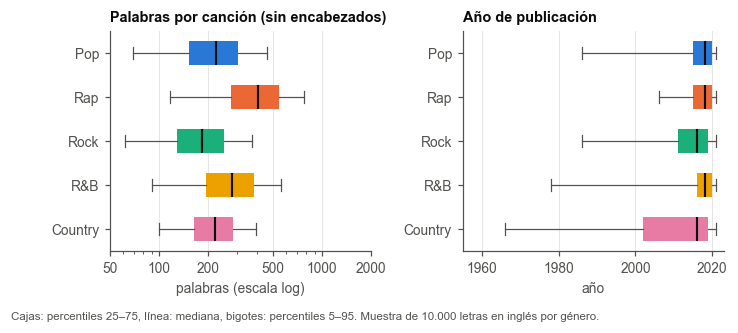

In [19]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.2, 2.6), gridspec_kw={"wspace": 0.35})
pos = np.arange(len(GENEROS))[::-1]
for eje, col, titulo, xlabel in [
    (a1, "n_palabras", "Palabras por canción (sin encabezados)", "palabras (escala log)"),
    (a2, "año", "Año de publicación", "año"),
]:
    datos = [muestra.loc[muestra["tag"] == g, col].dropna() for g in GENEROS]
    bp = eje.boxplot(datos, positions=pos, vert=False, widths=0.55, whis=(5, 95), showfliers=False,
                     patch_artist=True, medianprops={"color": TINTA, "lw": 1.4},
                     whiskerprops={"color": TINTA_2, "lw": 0.8}, capprops={"color": TINTA_2, "lw": 0.8},
                     boxprops={"lw": 0})
    for caja, g in zip(bp["boxes"], GENEROS):
        caja.set_facecolor(COLOR[g])
    eje.set_yticks(pos, [NOMBRE[g] for g in GENEROS])
    eje.set_title(titulo)
    eje.set_xlabel(xlabel)
    eje.grid(axis="y", visible=False)
a1.set_xscale("log")
a1.set_xticks([50, 100, 200, 500, 1000, 2000], ["50", "100", "200", "500", "1000", "2000"])
a2.set_xlim(1955, 2023)
fig.text(0.0, -0.13, "Cajas: percentiles 25–75, línea: mediana, bigotes: percentiles 5–95. "
         "Muestra de 10.000 letras en inglés por género.", fontsize=7.5, color=TINTA_2)
guardar(fig, "longitud_y_anio_por_genero")

## 6. Vocabulario distintivo

Las palabras más frecuentes son prácticamente las mismas en todos los géneros (*I, you, the, love*), por lo que la frecuencia bruta no permite caracterizarlos. Se utiliza el log-odds ratio con prior de Dirichlet informativo propuesto por Monroe, Colaresi y Quinn (2008, "Fightin' Words: Lexical Feature Selection and Evaluation for Identifying the Content of Political Conflict", *Political Analysis*, 16(4)), implementado en la función `log_odds_z`.

Para una palabra *w*, un grupo *i* y el resto del corpus *j*, a cada conteo $y_w$ se le suma un pseudo-conteo $\alpha_w$ proporcional a la frecuencia global de *w*. Este prior informativo acerca las estimaciones de las palabras poco frecuentes a su frecuencia global y evita cocientes extremos basados en pocos casos. Con los conteos suavizados se calcula la diferencia de log-odds

$$\delta_w = \log\frac{y_w^i+\alpha_w}{n_i+\alpha_0-y_w^i-\alpha_w} - \log\frac{y_w^j+\alpha_w}{n_j+\alpha_0-y_w^j-\alpha_w},$$

cuya varianza se aproxima por $\sigma^2 \approx \frac{1}{y_w^i+\alpha_w} + \frac{1}{y_w^j+\alpha_w}$. Las palabras se ordenan según $z = \delta_w/\sigma$.

La implementación difiere del artículo original en dos aspectos. En primer lugar, $y_w$ cuenta las canciones que contienen *w* y no sus ocurrencias, para que un estribillo repetido no domine el resultado. En segundo lugar, la intensidad del prior se controla con el parámetro `escala`, de modo que $\alpha_w$ es igual a `escala` multiplicado por la frecuencia global de *w*. Como el puntaje *z* tiende a favorecer las palabras frecuentes, la tabla principal excluye las palabras funcionales del inglés (lista `ENGLISH_STOP_WORDS` de scikit-learn).

In [20]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


def log_odds_z(docs_por_grupo, min_docs=30, escala=1.0, excluir=frozenset()):
    """Puntaje z del log-odds de cada palabra en un grupo frente al resto, con prior de Dirichlet informativo.

    docs_por_grupo: diccionario {grupo: serie de listas de tokens}. Se cuentan documentos que contienen
    cada palabra, no ocurrencias. escala: intensidad del prior (alpha_w = escala * frecuencia global de w).
    """
    cuentas = {g: Counter(w for toks in docs for w in set(toks)) for g, docs in docs_por_grupo.items()}
    total = sum(cuentas.values(), Counter())
    vocab = [w for w, c in total.items() if c >= min_docs and w not in excluir]
    frec = np.array([total[w] for w in vocab], dtype=float)
    a = escala * frec
    a0 = a.sum()
    salida = {}
    for g in cuentas:
        yi = np.array([cuentas[g][w] for w in vocab], dtype=float)
        yj = frec - yi
        ni, nj = yi.sum(), yj.sum()
        delta = np.log((yi + a) / (ni + a0 - yi - a)) - np.log((yj + a) / (nj + a0 - yj - a))
        salida[g] = pd.Series(delta / np.sqrt(1 / (yi + a) + 1 / (yj + a)), index=vocab)
    return pd.DataFrame(salida)


docs_genero = {g: muestra.loc[muestra["tag"] == g, "tokens"] for g in GENEROS}
z = log_odds_z(docs_genero, excluir=ENGLISH_STOP_WORDS)
distintivas = pd.DataFrame({NOMBRE[g]: z[g].nlargest(12).index for g in GENEROS})
distintivas.to_csv(TAB / "palabras_distintivas.csv", index=False)
distintivas

,Pop,Rap,Rock,R&B,Country
0,you're,bitch,death,baby,old
1,oh,niggas,blood,girl,town
2,we're,nigga,away,love,whiskey
3,love,shit,fear,ooh,country
4,feel,fuck,flesh,yeah,little
5,away,rap,inside,wanna,beer
6,it's,yo,dead,oh,road
7,heart,bitches,darkness,babe,home
8,know,ass,eyes,want,truck
9,i'm,em,endless,need,lonesome


La celda siguiente evalúa la sensibilidad del resultado a esas dos elecciones: compara los rankings con y sin palabras funcionales y con dos intensidades del prior, y cuenta cuántas palabras superan los umbrales $z > 5$ y $z > 10$ en cada género.

In [21]:
variantes = {
    "con palabras funcionales, prior 1": log_odds_z(docs_genero),
    "con palabras funcionales, prior 0,01": log_odds_z(docs_genero, escala=0.01),
    "sin palabras funcionales, prior 0,01": log_odds_z(docs_genero, escala=0.01, excluir=ENGLISH_STOP_WORDS),
}
for nombre, zv in variantes.items():
    print(f"{nombre}:")
    for g in GENEROS:
        print(f"   {NOMBRE[g]:8s}", ", ".join(zv[g].nlargest(8).index))
pd.DataFrame({"palabras con z > 5": (z > 5).sum(), "palabras con z > 10": (z > 10).sum(),
              "z máximo": z.max()}).T.rename(columns=NOMBRE)

con palabras funcionales, prior 1:
   Pop      you, i, you're, the, oh, to, and, are
   Rap      bitch, niggas, nigga, shit, fuck, rap, yo, bitches
   Rock     will, of, the, death, are, to, blood, and
   R&B      baby, girl, ooh, love, yeah, wanna, oh, babe
   Country  old, town, whiskey, well, country, beer, little, road
con palabras funcionales, prior 0,01:
   Pop      you, i, you're, the, oh, to, and, are
   Rap      bitch, shit, fuck, nigga, niggas, yo, em, bitches
   Rock     will, of, the, death, are, to, and, blood
   R&B      baby, girl, love, ooh, yeah, wanna, oh, babe
   Country  old, town, well, little, country, whiskey, road, beer
sin palabras funcionales, prior 0,01:
   Pop      you're, oh, we're, love, feel, away, it's, heart
   Rap      bitch, shit, fuck, nigga, niggas, yo, bitches, em
   Rock     death, blood, away, fear, inside, dead, eyes, darkness
   R&B      baby, girl, love, yeah, ooh, wanna, oh, want
   Country  old, town, little, country, home, road, whiskey, be

,Pop,Rap,Rock,R&B,Country
palabras con z > 5,23.0,559.0,95.0,70.0,171.0
palabras con z > 10,1.0,94.0,2.0,11.0,16.0
z máximo,10.1,34.7,11.4,24.3,18.3


Cuatro géneros presentan un vocabulario temático definido. En rap predominan insultos y jerga (*nigga, bitch, ass, lil*) junto con la autorreferencia *rap*; en R&B, la interpelación romántica y las interjecciones (*baby, girl, ooh, wanna*); en country, lugares y objetos de la vida rural (*whiskey, truck, road, town, beer*). En rock sobresale el léxico asociado al metal (*death, blood, fear, flesh, darkness*), y al incluir las palabras funcionales aparece además un registro más formal y en tercera persona (*their, will, of*).

El pop se distingue principalmente por un vocabulario emocional genérico (*love, feel, heart, away*), compartido con R&B y rock; si se incluyen las palabras funcionales, los primeros lugares corresponden a pronombres (*you, I*). El resultado que no depende de estas elecciones es la intensidad de la señal. El pop tiene 23 palabras con $z > 5$, frente a 559 en rap, 171 en country, 95 en rock y 70 en R&B, y una sola con $z > 10$. La intensidad del prior modifica la escala de los puntajes, pero no el orden de las palabras. Estos resultados no indican que el pop carezca de vocabulario propio, sino que ninguna palabra lo separa con claridad de los demás géneros, lo cual es compatible con su uso parcial como etiqueta residual (sección 1.2). De aquí surge la hipótesis de que el pop será la clase más difícil de clasificar y la que más se confundirá con R&B y rock.

## 7. Artistas en la muestra

Distribución de canciones por artista en la muestra y proporción de canciones de evaluación cuyo artista estaría presente en el entrenamiento con una partición aleatoria 80/20.

In [22]:
n_art = muestra.groupby("artist").size()
print(f"{muestra['artist'].nunique():,} artistas; canciones por artista: mediana {n_art.median():.0f}, "
      f"p99 {n_art.quantile(.99):.0f}, máx {n_art.max()} ({n_art.idxmax()})")
print(f"el 1% de artistas más prolíficos aporta el {n_art.nlargest(len(n_art) // 100).sum() / len(muestra):.1%} de la muestra")
from sklearn.model_selection import GroupShuffleSplit, train_test_split

tr, te = train_test_split(muestra.index, test_size=0.2, random_state=SEMILLA, stratify=muestra["tag"])
comparte = muestra.loc[te, "artist"].isin(set(muestra.loc[tr, "artist"])).mean()
print(f"con partición aleatoria 80/20, el {comparte:.1%} de las canciones de test tiene al artista en train")
pd.DataFrame({"artistas": muestra.groupby("tag")["artist"].nunique(),
              "canciones por artista (media)": muestra.groupby("tag").size() / muestra.groupby("tag")["artist"].nunique(),
              "artista más frecuente": muestra.groupby("tag")["artist"].agg(lambda s: s.value_counts().index[0]),
              "sus canciones": muestra.groupby("tag")["artist"].agg(lambda s: s.value_counts().iloc[0])}).pipe(por_genero)

33,401 artistas; canciones por artista: mediana 1, p99 8, máx 126 (Johnny Cash)
el 1% de artistas más prolíficos aporta el 10.1% de la muestra


con partición aleatoria 80/20, el 44.0% de las canciones de test tiene al artista en train


,artistas,canciones por artista (media),artista más frecuente,sus canciones
tag,,,,
pop,8614,1.2,Madonna,18
rap,8213,1.2,Lil B,18
rock,7812,1.3,The Grateful Dead,29
rb,6780,1.5,Chris Brown,35
country,3628,2.8,Johnny Cash,126


## 8. Control de fugas de información

Esta sección estima cuánta información aportan fuentes ajenas al contenido lingüístico de la letra. Se entrena un clasificador de referencia (TF-IDF con regresión logística) con una partición 80/20 y se evalúa con macro-F1. Se comparan la partición aleatoria y la agrupada por artista (`GroupShuffleSplit`), la letra con y sin encabezados, y dos modelos que no utilizan la letra, entrenados solo con los encabezados y solo con el año. Un desempeño alto de estos dos últimos indicaría la existencia de atajos disponibles para el clasificador.

In [23]:
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder

y = muestra["tag"].to_numpy()
tr_art, te_art = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEMILLA)
                      .split(muestra, y, groups=muestra["artist"]))
particiones = {"aleatoria": (np.asarray(tr), np.asarray(te)), "por artista": (tr_art, te_art)}
solo_enc = enc.map(lambda l: " ".join(l) if l else "_sin_encabezados_")
entradas = {
    "letra con encabezados": crudo,
    "letra sin encabezados": muestra["letra"],
    "solo los encabezados": solo_enc,
}
resultados = []
for nombre_part, (i_tr, i_te) in particiones.items():
    for nombre_ent, X in entradas.items():
        modelo = make_pipeline(TfidfVectorizer(min_df=3, max_features=100_000, sublinear_tf=True, token_pattern=r"(?u)\b\w+\b"),
                               LogisticRegression(max_iter=1000, C=4))
        modelo.fit(X.iloc[i_tr], y[i_tr])
        resultados.append((nombre_ent, nombre_part, f1_score(y[i_te], modelo.predict(X.iloc[i_te]), average="macro")))
    X_año = muestra[["año"]].fillna(0).astype(int).astype(str)
    m_año = make_pipeline(OneHotEncoder(handle_unknown="ignore"), LogisticRegression(max_iter=1000))
    m_año.fit(X_año.iloc[i_tr], y[i_tr])
    resultados.append(("solo el año", nombre_part, f1_score(y[i_te], m_año.predict(X_año.iloc[i_te]), average="macro")))
    dummy = DummyClassifier(strategy="most_frequent").fit(np.zeros((len(i_tr), 1)), y[i_tr])
    resultados.append(("clase mayoritaria", nombre_part, f1_score(y[i_te], dummy.predict(np.zeros((len(i_te), 1))), average="macro")))
fugas = pd.DataFrame(resultados, columns=["entrada", "partición", "macro-F1"]).pivot(index="entrada", columns="partición", values="macro-F1")
fugas = fugas.loc[["clase mayoritaria", "solo el año", "solo los encabezados", "letra con encabezados", "letra sin encabezados"]]
fugas["inflado por partición aleatoria"] = fugas["aleatoria"] - fugas["por artista"]
fugas.to_csv(TAB / "chequeo_fugas.csv", float_format="%.3f")
fugas.style.format("{:.3f}")

partición,aleatoria,por artista,inflado por partición aleatoria
entrada,,,
clase mayoritaria,0.067,0.065,0.002
solo el año,0.245,0.261,-0.015
solo los encabezados,0.362,0.349,0.013
letra con encabezados,0.602,0.595,0.008
letra sin encabezados,0.594,0.584,0.009


Con una única partición, diferencias del orden de 0,01 pueden deberse a la variabilidad del muestreo. Para comparar la partición aleatoria con la agrupada por artista se utiliza validación cruzada con cinco particiones (`StratifiedKFold` y `StratifiedGroupKFold`).

In [24]:
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, cross_val_score

def pipeline_texto():
    return make_pipeline(TfidfVectorizer(min_df=3, max_features=100_000, sublinear_tf=True, token_pattern=r"(?u)\b\w+\b"),
                         LogisticRegression(max_iter=1000, C=4))

cv = {
    "aleatoria (StratifiedKFold)": (StratifiedKFold(5, shuffle=True, random_state=SEMILLA), None),
    "por artista (StratifiedGroupKFold)": (StratifiedGroupKFold(5, shuffle=True, random_state=SEMILLA), muestra["artist"]),
}
for nombre_cv, (divisor, grupos) in cv.items():
    f1 = cross_val_score(pipeline_texto(), muestra["letra"], y, groups=grupos, cv=divisor, scoring="f1_macro")
    print(f"{nombre_cv:36s} macro-F1 {f1.mean():.3f} ± {f1.std():.3f}")

aleatoria (StratifiedKFold)          macro-F1 0.591 ± 0.005


por artista (StratifiedGroupKFold)   macro-F1 0.589 ± 0.005


La diferencia entre ambas particiones es menor que su desvío estándar, pese a que con la partición aleatoria el 44% de las canciones de evaluación comparte artista con el entrenamiento. La explicación más plausible es la baja cantidad de canciones por artista en la muestra (1,2 en promedio y 2,8 en country), que limita la posibilidad de memorizar artistas. La partición agrupada se mantiene por ser la metodológicamente correcta, pero el efecto debería reevaluarse con muestras más grandes o con el corpus completo, donde la mediana es de 2 canciones por artista y el máximo supera las 16.000.

Las señales ajenas a la letra, en cambio, resultan informativas: los encabezados por sí solos alcanzan un macro-F1 de entre 0,35 y 0,36, y el año, de entre 0,25 y 0,26, frente a 0,065 de la clase mayoritaria.

### Errores del clasificador de referencia

F1 por género y matriz de confusión normalizada por fila, con la partición agrupada por artista.

In [25]:
from sklearn.metrics import confusion_matrix

modelo = make_pipeline(TfidfVectorizer(min_df=3, max_features=100_000, sublinear_tf=True, token_pattern=r"(?u)\b\w+\b"),
                       LogisticRegression(max_iter=1000, C=4))
modelo.fit(muestra["letra"].iloc[tr_art], y[tr_art])
pred = modelo.predict(muestra["letra"].iloc[te_art])
confusion = pd.DataFrame(confusion_matrix(y[te_art], pred, labels=GENEROS, normalize="true") * 100,
                         index=[NOMBRE[g] for g in GENEROS], columns=[NOMBRE[g] for g in GENEROS])
print("F1 por género:", dict(zip(GENEROS, f1_score(y[te_art], pred, labels=GENEROS, average=None).round(2))))
confusion.rename_axis(index="real", columns="predicho")

F1 por género: {'pop': np.float64(0.37), 'rap': np.float64(0.78), 'rock': np.float64(0.56), 'rb': np.float64(0.54), 'country': np.float64(0.68)}


predicho,Pop,Rap,Rock,R&B,Country
real,,,,,
Pop,36.3,5.7,26.5,19.6,11.9
Rap,4.6,78.2,4.6,11.6,1.0
Rock,21.3,2.2,58.2,6.1,12.2
R&B,20.0,12.7,9.1,52.2,6.0
Country,13.3,2.2,11.1,5.6,67.9


## 9. Variación temporal dentro de cada género

La sección 5 trató el año como posible confusor entre géneros. Esta sección examina si el lenguaje de un mismo género cambia con el tiempo. En ese caso, un modelo entrenado mayoritariamente con canciones recientes (el 70% de la muestra es posterior a 2014) podría desempeñarse peor en otras épocas o utilizar la época como atajo. Se definen tres períodos con una cantidad suficiente de canciones por género.

In [26]:
muestra["época"] = pd.cut(muestra["año"], [1899, 2009, 2014, 2022], labels=["hasta 2009", "2010–2014", "2015–2022"])
pd.crosstab(muestra["época"], muestra["tag"])[GENEROS].rename(columns=NOMBRE)

tag,Pop,Rap,Rock,R&B,Country
época,,,,,
hasta 2009,1454,758,2182,1471,3281
2010–2014,861,1516,1510,478,1277
2015–2022,7678,7715,6307,8041,5437


### 9.1 Desempeño por período

Con el modelo de la sección 8 (partición agrupada por artista) se calculan el macro-F1 y el recall de cada género en cada período. La segunda tabla compara, para cada período, la distribución real de géneros en el conjunto de evaluación con la distribución predicha.

In [27]:
test = muestra.iloc[te_art].assign(pred=pred)
filas = {}
for e, d in test.groupby("época", observed=True):
    fila = {"n": len(d), "macro-F1": f1_score(d["tag"], d["pred"], average="macro")}
    fila.update({f"recall {NOMBRE[g]}": (d.loc[d["tag"] == g, "pred"] == g).mean() for g in GENEROS})
    filas[e] = fila
pd.DataFrame(filas).T.style.format("{:.2f}").format("{:,.0f}", subset=["n"])

,n,macro-F1,recall Pop,recall Rap,recall Rock,recall R&B,recall Country
hasta 2009,"1,772",0.56,0.26,0.84,0.48,0.51,0.74
2010–2014,"1,122",0.57,0.33,0.82,0.62,0.40,0.70
2015–2022,"6,957",0.58,0.39,0.77,0.61,0.53,0.63


In [28]:
reparto = {}
for e, d in test.groupby("época", observed=True):
    reparto[(e, "real")] = d["tag"].value_counts(normalize=True) * 100
    reparto[(e, "predicho")] = d["pred"].value_counts(normalize=True) * 100
pd.DataFrame(reparto).reindex(GENEROS).rename(index=NOMBRE)

hasta 2009          2010–2014          2015–2022         
              real predicho      real predicho      real predicho
Pop           15.5     16.4      15.5     16.2      22.1     20.4
Rap            8.8      9.1      27.1     24.2      21.5     22.2
Rock          23.8     21.5      26.9     26.8      18.4     21.5
R&B           14.3     14.3       8.1     10.2      23.9     21.9
Country       37.6     38.7      22.4     22.6      14.2     14.0

### 9.2 Cambios de vocabulario

Se aplica `log_odds_z` dentro de cada género para comparar las canciones hasta 2009 con las de 2015 a 2022, sin palabras funcionales. La celda posterior mide dos indicadores concretos del cambio: la proporción de canciones con al menos una grosería de una lista fija y la proporción de letras originales con apóstrofo tipográfico.

In [29]:
cambio = {}
for g in GENEROS:
    d = muestra[muestra["tag"] == g]
    zg = log_odds_z({"vieja": d.loc[d["época"] == "hasta 2009", "tokens"],
                     "nueva": d.loc[d["época"] == "2015–2022", "tokens"]}, min_docs=15, excluir=ENGLISH_STOP_WORDS)
    cambio[(NOMBRE[g], "hasta 2009")] = zg["vieja"].nlargest(10).index
    cambio[(NOMBRE[g], "2015–2022")] = zg["nueva"].nlargest(10).index
pd.DataFrame(cambio).T.apply(lambda f: ", ".join(f), axis=1).rename("palabras más distintivas").to_frame()

palabras más distintivas
Pop     hasta 2009               yes, woman, land, man, tree, children, lord, return, child, men
        2015–2022              wanna, fuck, shit, i'm, tryna, bitch, cause, yeah, don't, fucking
Rap     hasta 2009               tryin, funky, thug, mc's, rhyme, cats, c'mon, ghetto, hip, mack
        2015–2022               tryna, bitch, im, imma, aye, just, fucking, i'm, really, feeling
Rock    hasta 2009                          woman, baby, man, yeah, got, girl, oh, rock, ah, yes
        2015–2022         lost, fuck, fucking, shit, weight, flames, death, hope, thoughts, feel
R&B     hasta 2009                     yes, hey, funky, oh, ow, gonna, ooh, darling, honey, lord
        2015–2022                fuck, shit, tryna, nigga, bitch, fucking, niggas, im, imma, cuz
Country hasta 2009  yes, lord, woman, arms, lonesome, heartaches, he's, love, true, instrumental
        2015–2022              yeah, wanna, damn, ain't, gotta, tryna, shit, whiskey, hell, woah

In [30]:
GROSERIAS = {"fuck", "fucking", "shit", "bitch", "bitches", "damn", "ass", "nigga", "niggas"}
groseria = muestra["tokens"].map(lambda t: bool(GROSERIAS & set(t)))
curvo = crudo.str.contains("’")
pd.concat({
    "% con alguna grosería": pd.crosstab(muestra["época"], muestra["tag"], values=groseria, aggfunc="mean")[GENEROS] * 100,
    "% con apóstrofo tipográfico (’) en la letra cruda": pd.crosstab(muestra["época"], muestra["tag"], values=curvo, aggfunc="mean")[GENEROS] * 100,
}).rename(columns=NOMBRE)

tag                                                           Pop  Rap  Rock  R&B  Country
                                                  época                                   
% con alguna grosería                             hasta 2009  5.1 75.1   9.1  6.4      3.2
                                                  2010–2014  10.6 77.0  14.3 24.5      9.2
                                                  2015–2022  15.8 76.7  16.0 38.3     12.3
% con apóstrofo tipográfico (’) en la letra cruda hasta 2009 14.1 12.5  12.4 11.5      9.0
                                                  2010–2014  19.2 22.1  21.9 20.1     22.1
                                                  2015–2022  31.6 36.8  31.7 36.9     25.9

Los resultados muestran una variación sistemática: con el tiempo, el vocabulario de todos los géneros se acerca al del rap. La proporción de canciones con groserías pasa del 6% al 38% en R&B, del 5% al 16% en pop, del 3% al 12% en country y del 9% al 16% en rock, mientras que en rap se mantiene estable en torno al 76%. Entre las palabras distintivas del período reciente aparecen, en todos los géneros, *fuck, shit, tryna* o *imma*, y en el período anterior, *yes, lord, woman, darling* o *heartaches*. El rap también cambia internamente, de *rhyme, mc's, funky, thug* a *imma, aye, tryna*. Se observa además un cambio de formato: la proporción de letras con apóstrofo tipográfico pasa de entre 9% y 14% a entre 26% y 37%. Sin normalización, *don’t* y *don't* serían tokens distintos y el período podría filtrarse como rasgo tipográfico; `limpiar_letra` realiza esa normalización.

En el clasificador de referencia, el macro-F1 es estable entre períodos (de 0,56 a 0,58), pero el recall de cada género varía. El del pop aumenta de 0,26 a 0,39 y el del rock, de 0,48 a 0,61, mientras que el del country disminuye de 0,74 a 0,63 y el del rap, de 0,84 a 0,77. En cada período la distribución predicha es similar a la real, de modo que no hay evidencia de que el modelo utilice la época como atajo. Las variaciones de recall son compatibles con el cambio de vocabulario: el country anterior a 2010 conserva un léxico propio (*lord, lonesome, heartaches*), mientras que el country y el R&B recientes se aproximan al pop y al rap.

Estos resultados provienen de una única partición, y algunas combinaciones de período y género cuentan con alrededor de un centenar de canciones de evaluación, por lo que los valores de recall deben leerse como indicativos. Dado que el 70% de la muestra es posterior a 2014, las conclusiones se refieren principalmente a letras contemporáneas. Una evaluación temporal, con entrenamiento en canciones hasta 2014 y evaluación en las posteriores, junto con el reporte de métricas por período, permitiría medir este efecto de forma directa.

## 10. Resumen por género

Indicadores principales del corpus completo y de la muestra para cada género. La tabla se exporta a `reports/tablas/resumen_generos.csv`.

In [31]:
meta_g = meta[meta["tag"].isin(GENEROS)]
tabla = pd.DataFrame({
    "canciones en el dataset": meta_g.groupby("tag").size(),
    "% en bloque importado": meta_g.groupby("tag")["en_bloque"].mean() * 100,
    "% texto repetido o marcador": meta_g.assign(r=repetida[meta_g.index]).groupby("tag")["r"].mean() * 100,
    "% en inglés": porc_ingles,
    "año mediano": muestra.groupby("tag")["año"].median(),
    "palabras (mediana)": muestra.groupby("tag")["n_palabras"].median(),
    "% líneas repetidas": muestra.groupby("tag")["lineas_repetidas"].median(),
    "% con encabezados": tabla_enc["con_encabezados"],
    "artistas en la muestra": muestra.groupby("tag")["artist"].nunique(),
}).pipe(por_genero)
tabla.index = [NOMBRE[g] for g in tabla.index]
tabla.T.to_csv(TAB / "resumen_generos.csv", float_format="%.1f")
tabla.T.style.format("{:,.0f}", subset=pd.IndexSlice[["canciones en el dataset", "año mediano", "palabras (mediana)", "artistas en la muestra"], :]).format(
    "{:.1f}", subset=pd.IndexSlice[["% en bloque importado", "% texto repetido o marcador", "% en inglés", "% líneas repetidas", "% con encabezados"], :])

,Pop,Rap,Rock,R&B,Country
canciones en el dataset,"2,519,256","1,962,010","892,220","225,342","105,869"
% en bloque importado,43.0,1.5,13.9,6.3,18.3
% texto repetido o marcador,17.7,10.9,11.6,12.3,6.4
% en inglés,64.3,57.5,80.1,80.9,85.7
año mediano,"2,018","2,018","2,016","2,018","2,016"
palabras (mediana),225,405,184,281,221
% líneas repetidas,31.8,15.4,24.0,28.3,27.0
% con encabezados,56.1,69.9,41.0,62.7,59.9
artistas en la muestra,"8,614","8,213","7,812","6,780","3,628"


## 11. Síntesis

| | Observación | Magnitud | Tratamiento |
|---|---|---|---|
| 1 | Bloque de importación en el que pop funciona como etiqueta por defecto | 1,27 millones de filas; 43% del pop | Exclusión del bloque (`BLOQUE_IMPORTADO`) |
| 2 | Marcadores en lugar de letras (`[Instrumental]`, "Coming soon", etc.) | 14% del corpus con texto repetido; `[Instrumental]`, 10,6% | Exclusión de textos repetidos y de letras con menos de 20 palabras |
| 3 | Idioma asociado al género | Letras en inglés: 57,5% en rap, 64,3% en pop, 85,7% en country | Se conservan solo letras en inglés |
| 4 | Cuentas de traducción de Genius registradas como artistas | 74.350 canciones en 151 cuentas | Exclusión |
| 5 | Encabezados con nombres de artistas y convenciones de transcripción, con y sin corchetes | Macro-F1 de 0,35 a 0,36 usando solo encabezados | Eliminación antes del modelado |
| 6 | Año como confusor entre géneros | Macro-F1 de 0,25 a 0,26 usando solo el año | No se usa como atributo; métricas por período |
| 7 | Años fuera de rango | 20.880 anteriores a 1900 (80% en `misc`) y 988 posteriores a 2022 | Tratados como faltantes |
| 8 | Fuga por artista baja en la muestra | Macro-F1 de 0,591 (aleatoria) y 0,589 (por artista) en validación cruzada | Partición agrupada por artista |
| 9 | Señal léxica débil del pop | 23 palabras con $z > 5$ (559 en rap); F1 de 0,37 (0,78 en rap) | Hipótesis de análisis |
| 10 | Variación temporal del vocabulario y del formato | Groserías en R&B: de 6% a 38%; apóstrofo tipográfico: de 9%–14% a 26%–37% | Normalización de apóstrofos; evaluación por período |
| 11 | `misc` compuesto por literatura, discursos, textos religiosos y cuentas de plataformas | Los 20 autores principales suman el 8,2% | Exclusión por no ser un género musical |

La muestra resultante contiene 50.000 canciones (10.000 por género) de 33.401 artistas, en inglés, sin encabezados, sin duplicados y fuera del bloque de importación. Se reproduce con `python -m src.muestra` y semilla 42. El clasificador de referencia (TF-IDF con regresión logística sobre la letra limpia y partición agrupada por artista) alcanza un macro-F1 de 0,59, frente a 0,065 de la clase mayoritaria.

Del análisis surgen las siguientes preguntas para la etapa de modelado:

1. Qué parte de la información sobre el género proviene del contenido (vocabulario, temas) y qué parte de la forma (longitud, repetición, diversidad léxica). El rap se separa en ambas dimensiones; rock y country, solo en la primera.
2. Si el pop constituye un género lingüísticamente definido o una etiqueta residual, lo que puede estudiarse mediante la matriz de confusión, modelos de tópicos (LDA) y la comparación con una tarea que excluya al pop.
3. Cuánto mejoran las representaciones basadas en embeddings o en transformers respecto de TF-IDF, controlando por período.
4. Qué tan estable es el clasificador en el tiempo, mediante una partición temporal (sección 9).